In [29]:
import pandas as pd

from xgboost import XGBRegressor

import matplotlib.pyplot as plt

In [30]:
last_df = pd.read_excel("./data/mCALR-N step data-17mar2026.xlsx", header = 1)
last_df = last_df[2:].reset_index(drop = True)
last_df.columns = ["Batch", "Batch Full Name"] + last_df.columns[2:].tolist()

target_var = "STR2K_D14_4_1_PA_HPLC_Concentration"
last_df[["Batch", target_var]]

,Batch,STR2K_D14_4_1_PA_HPLC_Concentration
0,FA001,5.19
1,FA002,4.86
2,FA003,4.63
3,FA004,4.62
4,FA005,3.91
5,FA006,5.63
6,FA007,5.79
7,FA008,5.89
8,FA009,4.84
9,FA010,5.56


In [32]:
ts_df = pd.read_excel("./data/mCALR-N step data-17mar2026.xlsx", header = 1, sheet_name = 1)
ts_df

,Run,Process Time [h],Ammonia [mg/L],Bolus Feed A Daily Qty [kg],Bolus Glucose Daily Qty [kg],Bolus Feed B Daily Qty [kg],Glucose [mg/L],Glutamate [mg/L],Glutamine [mg/L],IgG [g/L],Lactate [mg/L],LDH [dimensionless],Offline pH preadusjtement [dimensionless],Online pH primary probe preadusjtement [dimensionless],Online pH secondary probe preadusjtement [dimensionless],pCO2 preadusjtement [mmHg],pH offset [],pO2 preadusjtement [mmHg],VCD [Mc/mL],Viability [%]
0,FA001_MCALR N-PROD 2000L_1003145,49.646944,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.04,NaN,NaN,NaN,NaN,NaN,NaN
1,FA001_MCALR N-PROD 2000L_1003145,49.650000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.05,NaN,NaN,NaN,NaN,NaN
2,FA001_MCALR N-PROD 2000L_1003145,49.746667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.047,NaN,NaN,NaN,-0.067209,NaN,NaN,NaN
3,FA001_MCALR N-PROD 2000L_1003145,49.750556,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,101.0,NaN,NaN,NaN,NaN
4,FA001_MCALR N-PROD 2000L_1003145,49.751944,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,136.1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3322,FA011_MCALR N-PROD 2000L_1004660,377.617222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2665.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3323,FA011_MCALR N-PROD 2000L_1004660,377.621111,134.331,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3324,FA011_MCALR N-PROD 2000L_1004660,377.623333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.113,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3325,FA011_MCALR N-PROD 2000L_1004660,377.626944,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5893.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df = pd.read_excel("./data/mCALR N-1.xlsx", header = 1)
df = df[2:].reset_index(drop = True)
df = df.tail(6)
df.columns = ["Batch", "Batch Full Name"] + df.columns[2:].tolist()
df

,Batch,Batch Full Name,Generic.Bioreactor.End Culture.Culture duration,Generic.Bioreactor.Equipment parameters at inoculation.Air sparger,Generic.Bioreactor.Equipment parameters at inoculation.pH primary probe,Generic.Bioreactor.Pre-Inoculation.pCO2,Generic.Bioreactor.Pre-Inoculation.pH,Generic.Bioreactor.Pre-Inoculation.pO2,0.8X HIP MEDIUM,1M Sodium Carbonate Solution,CAMPAIGN,Glucose 500 g/L,OPTICHO GROWTH MEDIUM
5,FA006,FA006_MCALR N-1 STR200L_1004441,168,2.004,6.81,10.6,7.76,139.4,1004164.0,1004090.0,FA006,1003732.0,1004329.0
6,FA007,FA007_MCALR N-1 STR200L_1004444,168,2.004,6.8,10,7.787,135.7,1004328.0,1004090.0,FA007,1004089.0,1004369.0
7,FA008,FA008_MCALR N-1 STR200L_1004445,171,2.004,6.82,10,7.776,138.5,1004384.0,1004090.0,FA008,1004089.0,1004407.0
8,FA009,FA009_MCALR N-1 STR200L_1004488,170,1.003,6.82,10.6,7.715,129.9,1004420.0,1004090.0,FA009,1004089.0,1004494.0
9,FA010,FA010_MCALR N-1 STR200L_1004546,167,2.004,6.84,10,7.851,137.9,1004446.0,1004090.0,FA010,1004089.0,1004549.0
10,FA011,FA011_MCALR N-1 STR200L_1004732,167,2.004,6.8,10,7.853,133.5,1004511.0,1004090.0,FA011,1004274.0,1004596.0


In [17]:
X = df[[col for col in df.columns if "Generic" in col]]
X

,Generic.Bioreactor.End Culture.Culture duration,Generic.Bioreactor.Equipment parameters at inoculation.Air sparger,Generic.Bioreactor.Equipment parameters at inoculation.pH primary probe,Generic.Bioreactor.Pre-Inoculation.pCO2,Generic.Bioreactor.Pre-Inoculation.pH,Generic.Bioreactor.Pre-Inoculation.pO2
5,168,2.004,6.81,10.6,7.76,139.4
6,168,2.004,6.8,10,7.787,135.7
7,171,2.004,6.82,10,7.776,138.5
8,170,1.003,6.82,10.6,7.715,129.9
9,167,2.004,6.84,10,7.851,137.9
10,167,2.004,6.8,10,7.853,133.5


In [18]:
from sklearn.tree import DecisionTreeRegressor

In [22]:
model = XGBRegressor()
model.fit(X.astype(float), last_df[target_var][-6:])

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [23]:
imp_df = pd.DataFrame({"Feature": X.columns, "Importance": model.feature_importances_}).sort_values(by = "Importance")
imp_df

,Feature,Importance
4,Generic.Bioreactor.Pre-Inoculation.pH,0.000000
1,Generic.Bioreactor.Equipment parameters at ino...,0.000053
2,Generic.Bioreactor.Equipment parameters at ino...,0.000201
0,Generic.Bioreactor.End Culture.Culture duration,0.008034
3,Generic.Bioreactor.Pre-Inoculation.pCO2,0.013630
5,Generic.Bioreactor.Pre-Inoculation.pO2,0.978082


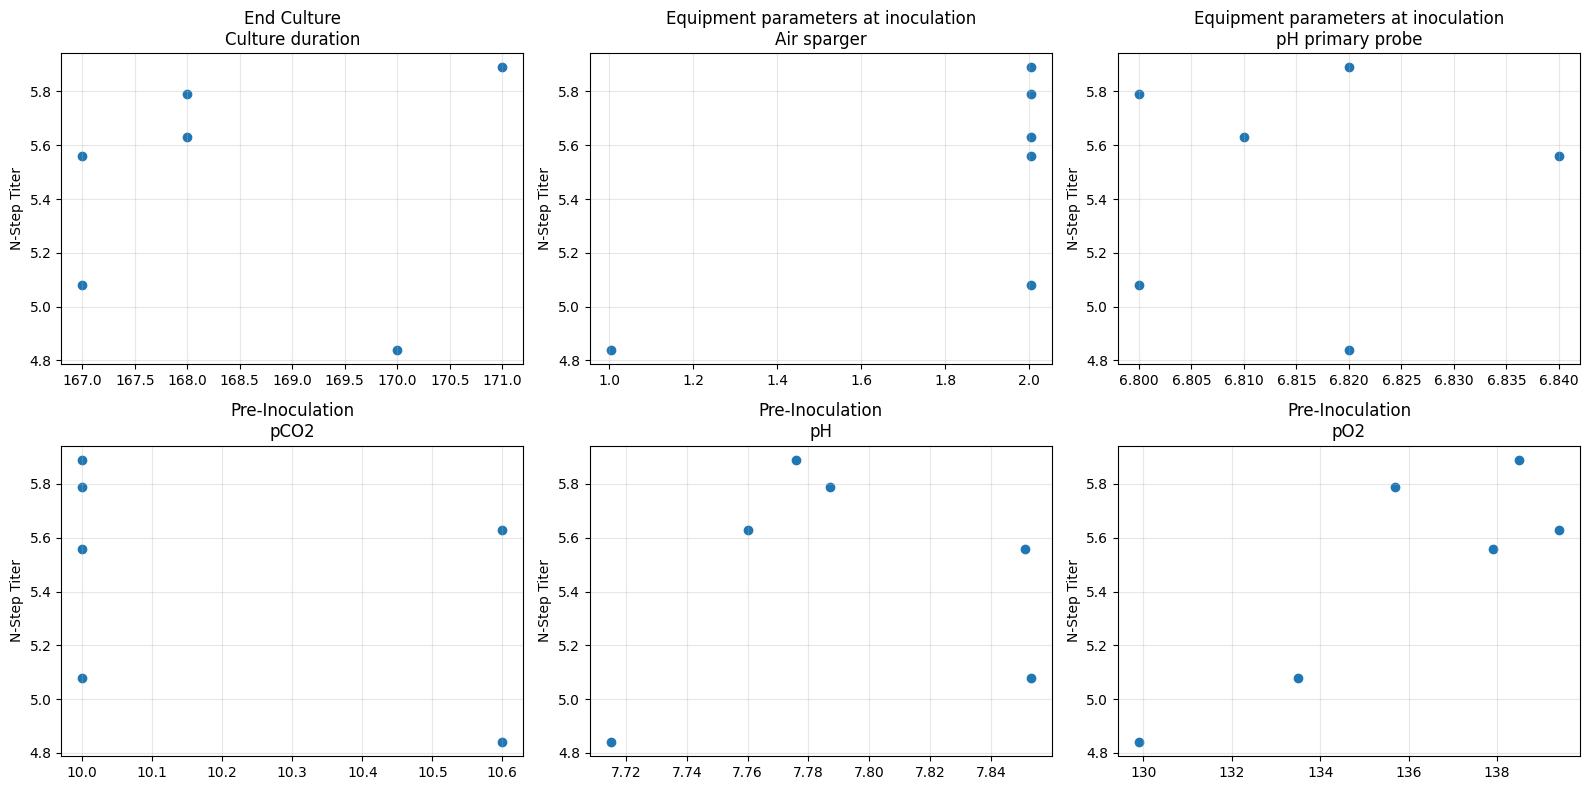

In [26]:
fig, axs = plt.subplots(2, 3, figsize = (16, 8))

for idx, col in enumerate(X.columns):
    row_idx = idx // 3
    col_idx = idx % 3

    ax = axs[row_idx][col_idx]

    x_s = X[col].astype(float)

    ax.scatter(x_s, last_df[target_var][-6:])
    ax.set_title("\n".join(col.split(".")[2:]))
    ax.set_ylabel("N-Step Titer")
    ax.grid(alpha = 0.3)

fig.tight_layout()
fig.show()

In [28]:
last_df

,Batch,Batch Full Name,CNT_CAT_VAR_MES,CNT_SCALAR_MES,CNT_TIME_DATA_MES,CNT_TIME_VAR_MES,Generic.Bioreactor.End Culture.Bolus antifoam.Total Qty,Generic.Bioreactor.End Culture.Bolus base.Total Qty,Generic.Bioreactor.End Culture.Cell age at harvest,Generic.Bioreactor.End Culture.Culture duration,...,STR2K_D14_4_1_PA_HPLC_Concentration,1M Sodium Carbonate Solution,CAMPAIGN,Cell Boost 7a feed medium,Cell Boost 7b feed medium,Glucose 500 g/L,Location,MO_BR_REP_STATUS,OPTICHO GROWTH MEDIUM,SKU
0,FA001,FA001_MCALR N-PROD 2000L_1003145,9,25,318,21,2.462,21.128,36,331,...,5.19,1003086.0,FA001,1003097.0,1003096.0,1003060.0,YVE Bioplant,NaN,1003078.0,20001496.0
1,FA002,FA002_MCALR N-PROD 2000L_1003309,9,25,315,21,1.561,21.957,36,331,...,4.86,1003086.0,FA002,1003269.0,1003268.0,1003060.0,YVE Bioplant,NaN,1003211.0,20001496.0
2,FA003,FA003_MCALR N-PROD 2000L_1003389,9,25,315,21,1.38,22.126,36,332,...,4.63,1003086.0,FA003,1003364.0,1003365.0,1003060.0,YVE Bioplant,NaN,1003311.0,20001496.0
3,FA004,FA004_MCALR N-PROD 2000L_1004167,9,25,313,21,1.754,-1.295,36,333,...,4.62,1004000.0,FA004,1004094.0,1004095.0,1004093.0,YVE Bioplant,NaN,1004092.0,20001496.0
4,FA005,FA005_MCALR N-PROD 2000L_1004168,10,25,311,21,1.78,0.15,36,334,...,3.91,1004000.0,FA005,1004165.0,1004095.0,1004093.0,YVE Bioplant,NaN,1004150.0,20001496.0
5,FA006,FA006_MCALR N-PROD 2000L_1004480,10,25,313,21,3.484,0.003,36,333,...,5.63,1004090.0,FA006,1004348.0,1004349.0,1004093.0,YVE Bioplant,NaN,1004329.0,20001496.0
6,FA007,FA007_MCALR N-PROD 2000L_1004483,10,25,315,21,4.396,-2.723,36,332,...,5.79,1004090.0,FA007,1004370.0,1004371.0,1004093.0,YVE Bioplant,NaN,1004369.0,20001496.0
7,FA008,FA008_MCALR N-PROD 2000L_1004510,10,25,318,21,3.36,-1.333,36,331,...,5.89,1004090.0,FA008,1004447.0,1004371.0,1004467.0,YVE Bioplant,En brouillon,1004407.0,20001496.0
8,FA009,FA009_MCALR N-PROD 2000L_1004561,10,25,316,21,3.63,-3.878,36,332,...,4.84,1004090.0,FA009,1004547.0,1004448.0,1004467.0,YVE Bioplant,NaN,1004494.0,20001496.0
9,FA010,FA010_MCALR N-PROD 2000L_1004602,11,25,315,21,4.292,-0.485,36,329,...,5.56,1004090.0,FA010,1004594.0,1004713.0,1004467.0,YVE Bioplant,En brouillon,1004549.0,20001496.0
